# Multiphase Galactic Wind Models Tutorial

This notebook demonstrates how to:
1. Set up and run wind models
2. Plot wind properties
3. Calculate observables for comparison with data
4. Explore parameter dependencies

Based on Fielding & Bryan (2024): "The Structure of Multiphase Galactic Winds"

## 1. Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
# Add parent directory to path
import sys
sys.path.insert(0, '..')

# Import the package
from multiphasegalacticwind import WindModel, WindConfig
from multiphasegalacticwind import (
    plot_wind_solution, 
    plot_velocity_distribution,
    plot_column_density_distribution
)
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Set up nice plotting
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

## 2. Basic Wind Model

Let's start with a simple wind model using default parameters.

In [3]:
# Create a basic wind model
model = WindModel(
    SFR=20.0,           # Star formation rate [Msun/yr]
    eta_M=0.1,          # Hot phase mass loading
    eta_M_cold=0.01,     # Cold phase mass loading
    cloud_mass_range=(1e2, 1e7), # Msun, min and max cloud mass
    N_cloud_species=6,  # Number of cloud mass bins
    r_max_kpc=30.0,     # Maximum integration radius
    rtol=1e-6           # Relaxed tolerance for speed
)

print("Model parameters:")
print(f"  Star formation rate: {model.SFR} Msun/yr")
print(f"  Hot mass loading: {model.eta_M}")
print(f"  Cold mass loading: {model.eta_M_cold}")
print(f"  Number of cloud species: {model.N_cloud_species}")
print(f"  Initial cloud masses: {model.M_cloud0/1.989e33} Msun")

Model parameters:
  Star formation rate: 20.0 Msun/yr
  Hot mass loading: 0.1
  Cold mass loading: 0.01
  Number of cloud species: 6
  Initial cloud masses: [1.00553042e+02 1.00553042e+03 1.00553042e+04 1.00553042e+05
 1.00553042e+06 1.00553042e+07] Msun


## 3. Run the Model

Now let's integrate the wind equations and examine the solution.

In [4]:
# Run the model
print("Running wind integration...")
solution = model.run()

# Check integration results
print(f"\nIntegration completed!")
print(f"  Final radius: {solution.r[-1]:.1f} kpc")
print(f"  Final velocity: {solution.v[-1]:.1f} km/s")
print(f"  Final temperature: {solution.T[-1]:.2e} K")
print(f"  Number of steps: {len(solution.r)}")

# Key diagnostics at 10 kpc (if reached)
if solution.r[-1] >= 10:
    print(f"\nProperties at 10 kpc:")
    print(f"  Wind velocity: {solution.v_at_10kpc:.1f} km/s")
    print(f"  Mass loading factor: {solution.mass_loading_at_10kpc:.2f}")

Running wind integration...

Integration completed!
  Final radius: 0.3 kpc
  Final velocity: 1581.1 km/s
  Final temperature: 1.13e+08 K
  Number of steps: 1


/Users/dbf75/Work/Research/GalacticWindsMultiphaseAnalytic/examples/../multiphasegalacticwind/core_physics.py:349: RuntimeWarning: invalid value encountered in power
  r_cloud = (M_cloud / (4*np.pi/3. * rho_cloud))**(1/3.)


## 4. Plot Wind Properties

Let's visualize the wind evolution using the built-in plotting function.

/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_28073/3919130766.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_28073/3919130766.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


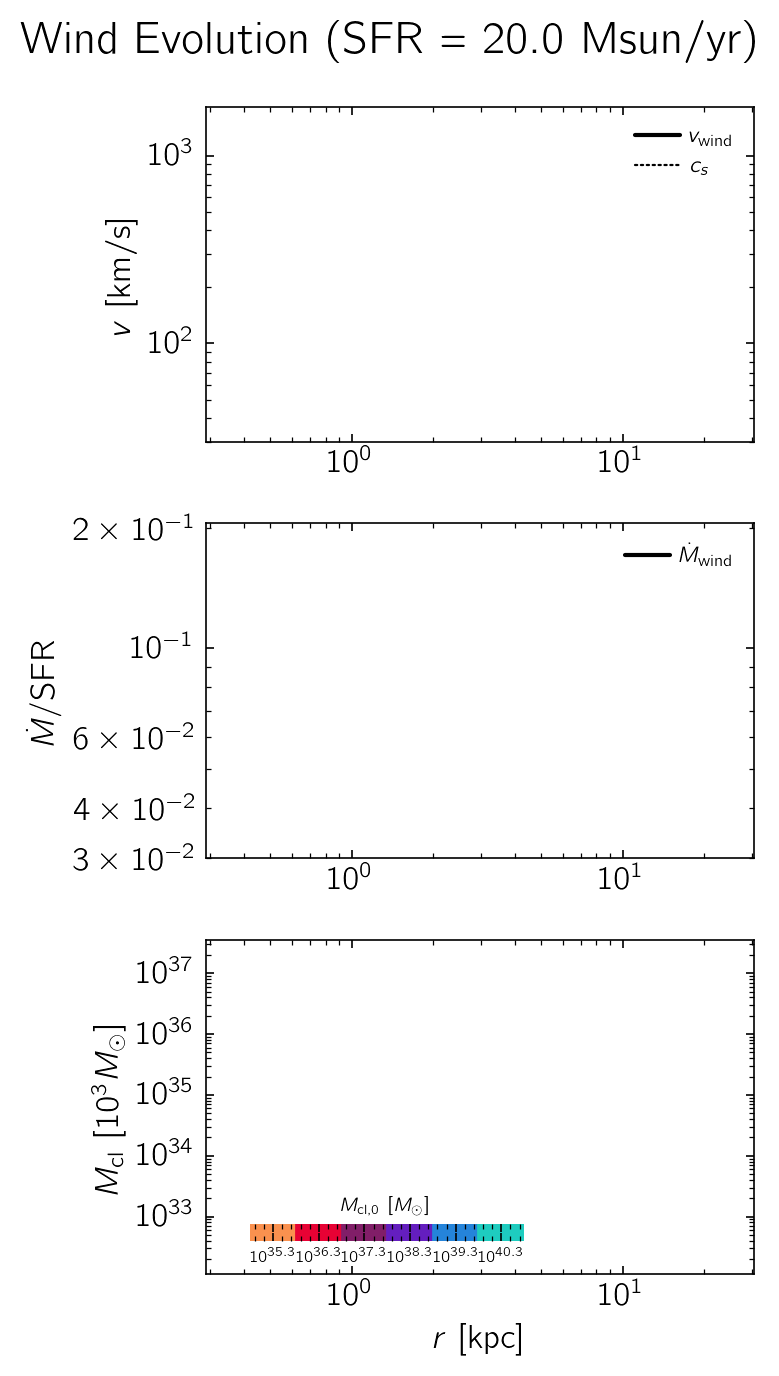

In [5]:
# Create comprehensive wind plots
fig, axes = plot_wind_solution(solution, show_hot_only=False, show_clouds=True)
fig.suptitle(f'Wind Evolution (SFR = {model.SFR} Msun/yr)', fontsize=16)
plt.tight_layout()

## 5. Velocity Distributions

Calculate and plot the velocity distribution of clouds - this is what observers measure!

/Users/dbf75/Work/Research/GalacticWindsMultiphaseAnalytic/examples/../multiphasegalacticwind/observables.py:122: RuntimeWarning: divide by zero encountered in divide
  dN_dv = np.where(np.abs(dv_dr) > 1e-10, n_cloud / np.abs(dv_dr), 0)


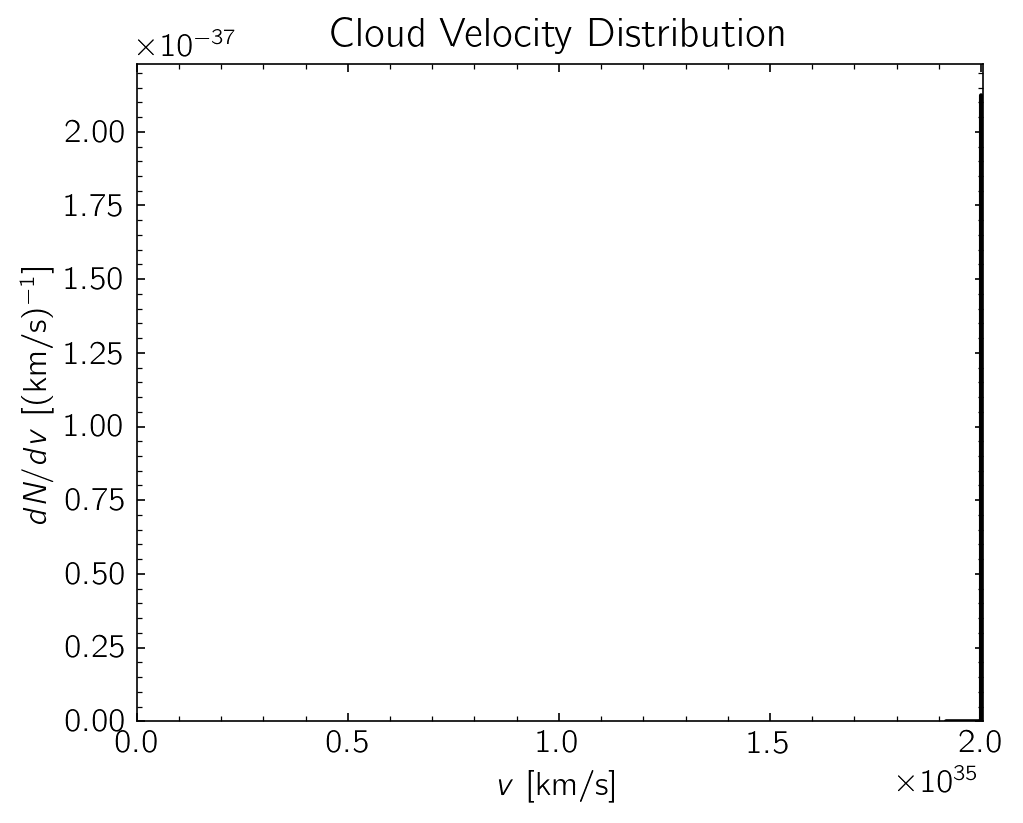

In [ ]:
# Calculate velocity distribution
v_cloud, dN_dv = solution.calculate_velocity_distribution()

# Calculate moments
moments = solution.calculate_velocity_moments()

# Plot velocity distribution
fig, ax = plot_velocity_distribution(solution, show_moments=True)
ax.set_title('Cloud Velocity Distribution')

# Print moments if available
if 'mean' in moments:
    print(f"Velocity moments:")
    print(f"  Mean velocity: {moments['mean']:.1f} km/s")
    print(f"  Velocity dispersion: {moments['dispersion']:.1f} km/s")
    if 'skewness' in moments:
        print(f"  Skewness: {moments['skewness']:.2f}")

## 6. Column Density Distribution

For absorption line studies, we need the column density distribution dN/dv in proper units.

/Users/dbf75/Work/Research/GalacticWindsMultiphaseAnalytic/examples/../multiphasegalacticwind/observables.py:259: RuntimeWarning: divide by zero encountered in divide
  dN_dr / np.abs(dv_dr) * 1e5,  # multiply by 1e5 for km/s units
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/2148610646.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Total column density integral: {np.trapz(dN_dv_dict['total'], v_cloud):.2e} cm^-2")


Total column density integral: -9.20e+12 cm^-2


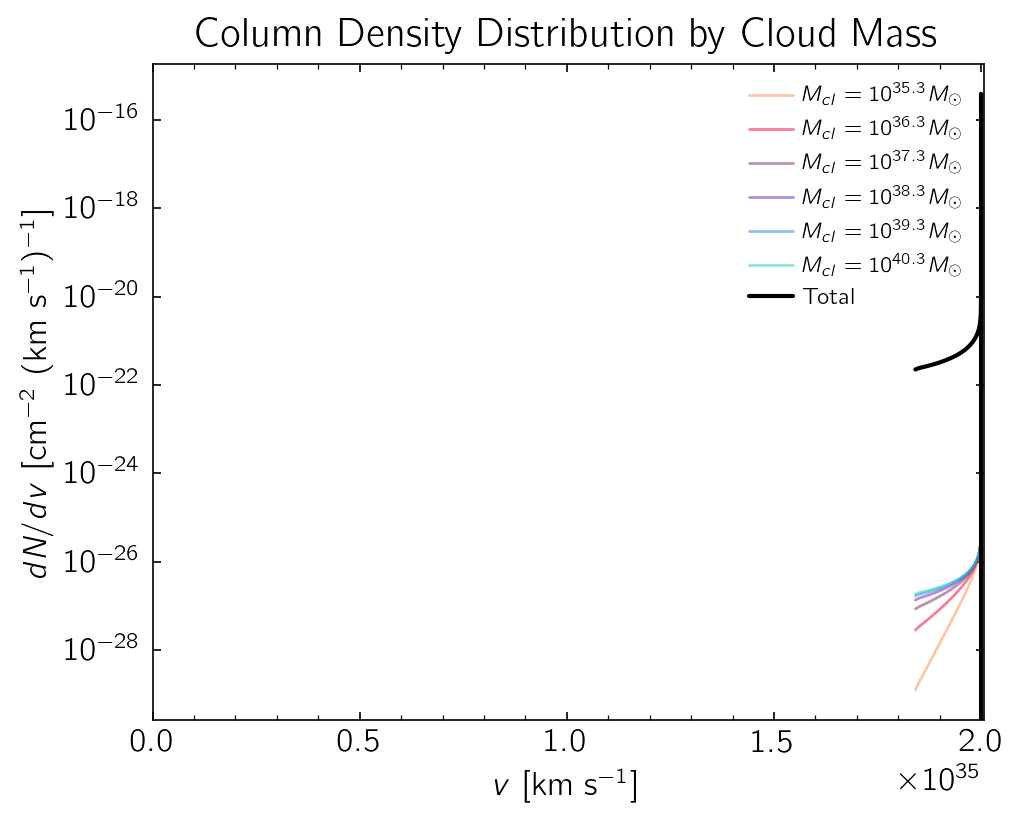

In [ ]:
# Calculate column density distribution
v_cloud, dN_dv_column = solution.calculate_column_density_distribution()

# Plot with individual cloud contributions
fig, ax = plot_column_density_distribution(solution, show_species=True, log_scale=True)
ax.set_title('Column Density Distribution by Cloud Mass')

# Get contributions from each cloud species
v_cloud, dN_dv_dict = solution.calculate_column_density_by_species()
print(f"Total column density integral: {np.trapz(dN_dv_dict['total'], v_cloud):.2e} cm^-2")

## 7. Parameter Studies

Let's explore how key parameters affect the wind solution.

### 7.1 Turbulent Mixing Efficiency

<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/3944436934.py:35: SyntaxWarning: invalid escape sequence '\o'
  axes[3].set(xlabel='r [kpc]', ylabel='$M_{cloud,tot}$ [M$_\odot$]', title='Total Cloud Mass')


Running model with f_turb = 0.05...
Running model with f_turb = 0.1...
Running model with f_turb = 0.2...


/Users/dbf75/Work/Research/GalacticWindsMultiphaseAnalytic/examples/../multiphasegalacticwind/core_physics.py:349: RuntimeWarning: invalid value encountered in power
  r_cloud = (M_cloud / (4*np.pi/3. * rho_cloud))**(1/3.)


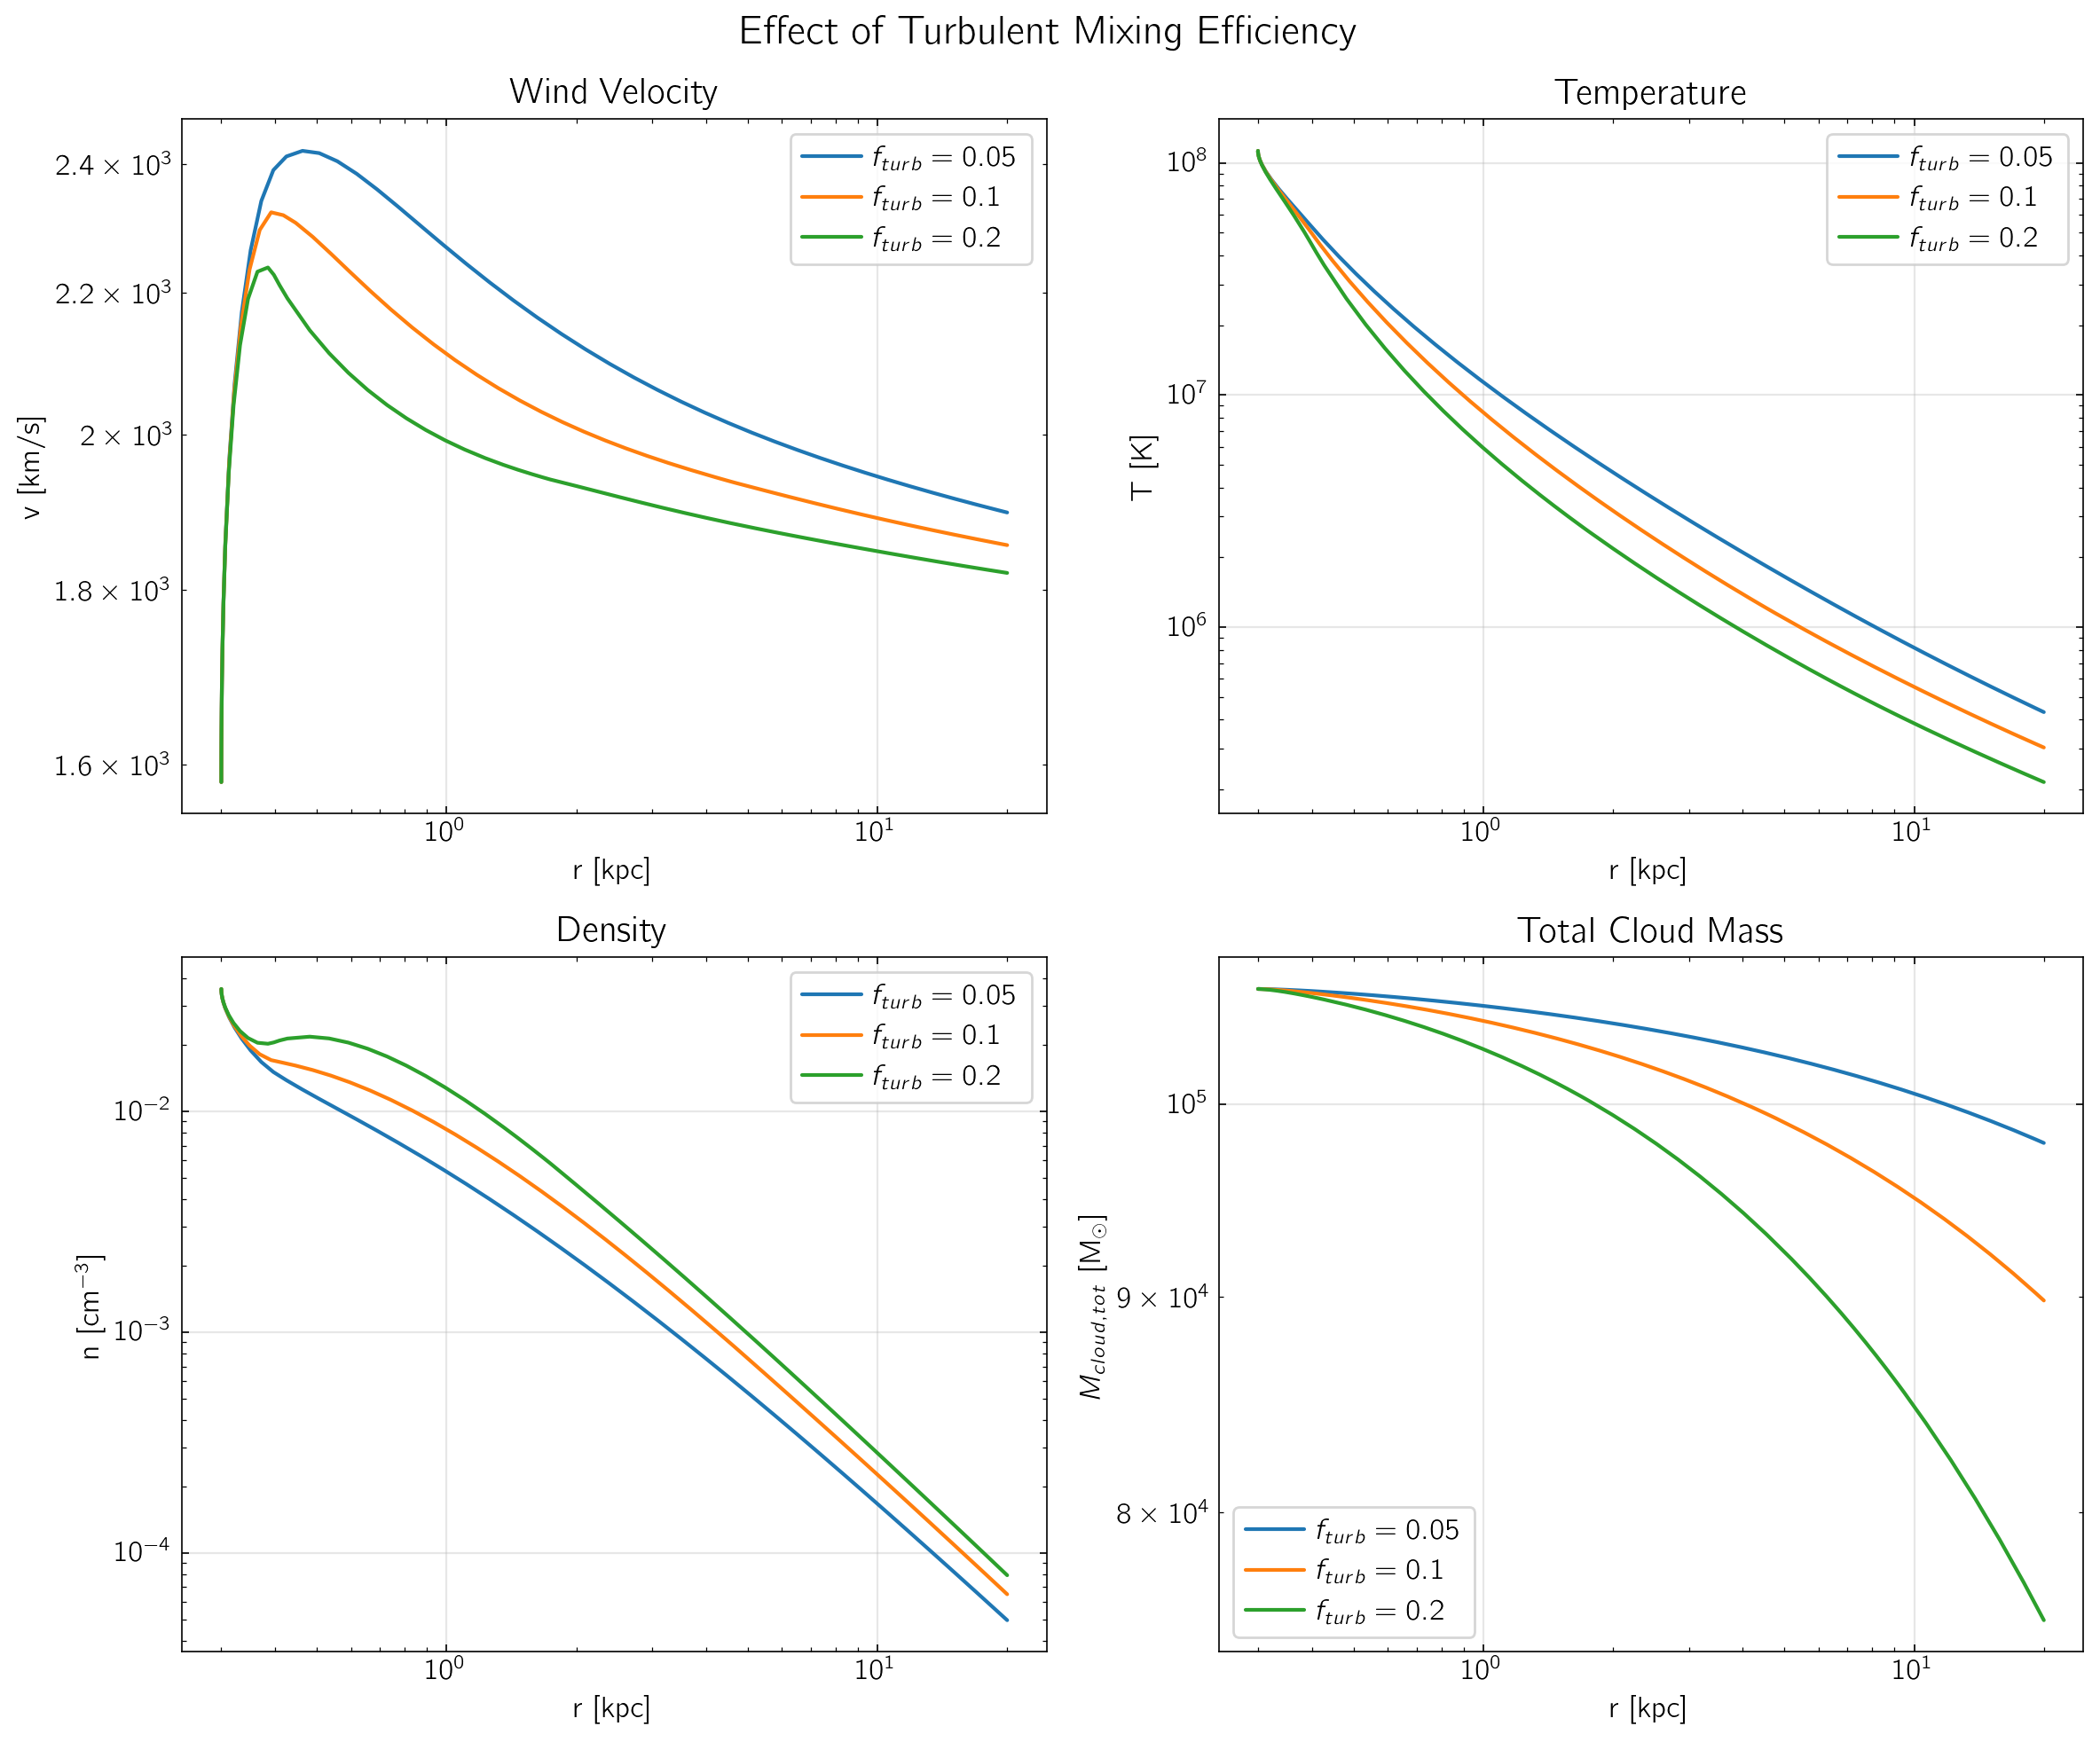

In [ ]:
# Compare different turbulent mixing efficiencies
f_turb_values = [0.05, 0.1, 0.2]
solutions_fturb = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for f_turb in f_turb_values:
    # Create model with custom f_turb
    config = WindConfig(f_turb0=f_turb)
    model_ft = WindModel(
        SFR=10.0,
        N_cloud_species=5,
        config=config,
        r_max_kpc=20.0,
        rtol=1e-6
    )
    
    # Run and store
    print(f"Running model with f_turb = {f_turb}...")
    sol = model_ft.run()
    solutions_fturb.append(sol)
    
    # Plot results
    label = f'$f_{{turb}} = {f_turb}$'
    axes[0].loglog(sol.r, sol.v, label=label)
    axes[1].loglog(sol.r, sol.T, label=label)
    axes[2].loglog(sol.r, sol.n, label=label)
    axes[3].loglog(sol.r, sol.M_cloud_tot/1.989e33, label=label)

# Format plots
axes[0].set(xlabel='r [kpc]', ylabel='v [km/s]', title='Wind Velocity')
axes[1].set(xlabel='r [kpc]', ylabel='T [K]', title='Temperature')
axes[2].set(xlabel='r [kpc]', ylabel='n [cm$^{-3}$]', title='Density')
axes[3].set(xlabel='r [kpc]', ylabel='$M_{cloud,tot}$ [M$_\odot$]', title='Total Cloud Mass')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Turbulent Mixing Efficiency', fontsize=16)
plt.tight_layout()

### 7.2 Mass Loading Comparison

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/2467310349.py:20: SyntaxWarning: invalid escape sequence '\e'
  ax1.loglog(sol.r, sol.v, color=colors[i], label=f'$\eta_M = {eta_M}$')
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/2467310349.py:21: SyntaxWarning: invalid escape sequence '\e'
  ax2.loglog(sol.r, sol.Mdot, color=colors[i], label=f'$\eta_M = {eta_M}$')
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/2467310349.py:24: SyntaxWarning: invalid escape sequence '\d'
  ax2.set(xlabel='r [kpc]', ylabel='$\dot{M}$ [M$_\odot$/yr]', title='Mass Flux')


Running model with eta_M = 0.05...
Running model with eta_M = 0.1...
Running model with eta_M = 0.2...


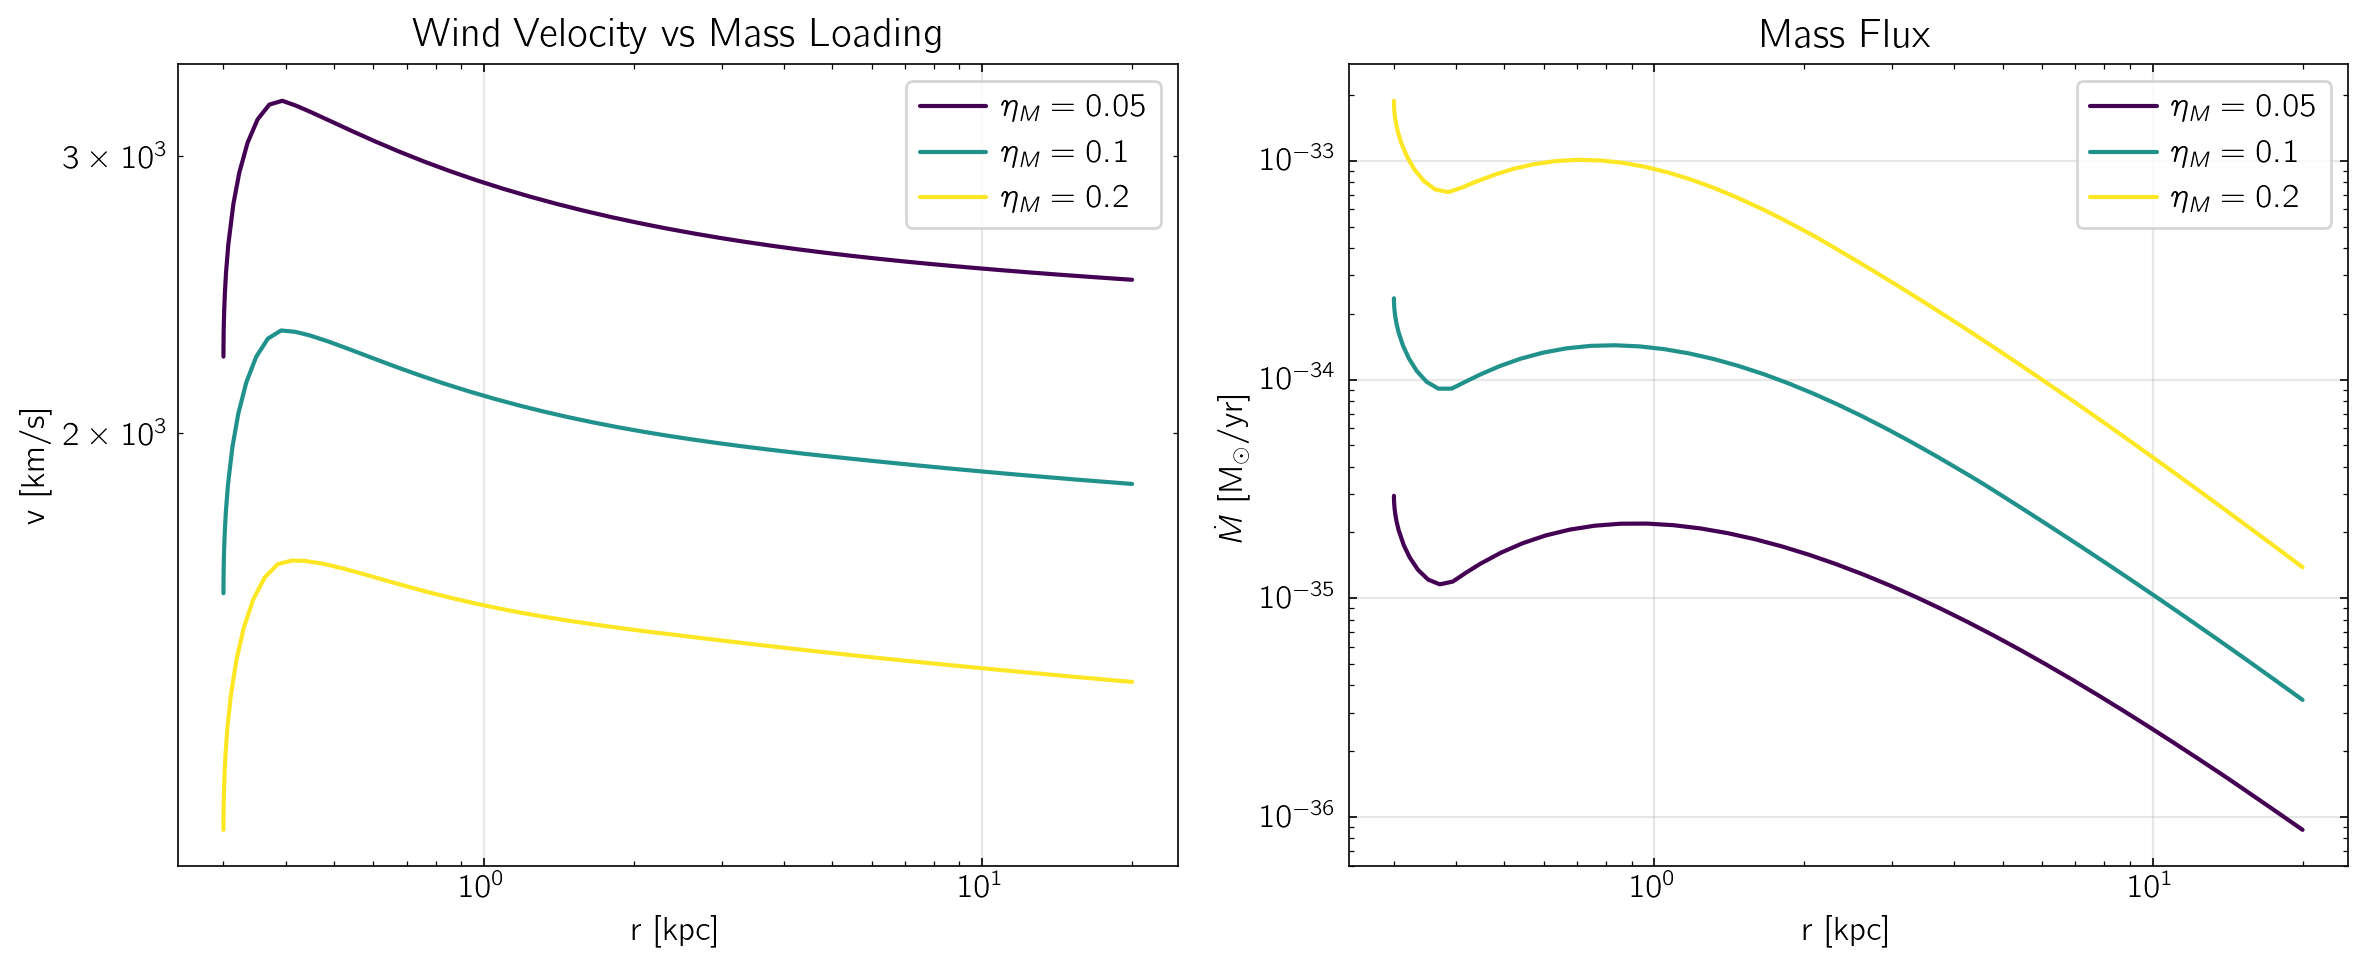

In [ ]:
# Compare different mass loading factors
eta_M_values = [0.05, 0.1, 0.2]
colors = plt.cm.viridis(np.linspace(0, 1, len(eta_M_values)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, eta_M in enumerate(eta_M_values):
    model_eta = WindModel(
        SFR=10.0,
        eta_M=eta_M,
        N_cloud_species=5,
        r_max_kpc=20.0,
        rtol=1e-6
    )
    
    print(f"Running model with eta_M = {eta_M}...")
    sol = model_eta.run()
    
    # Plot velocity and mass flux
    ax1.loglog(sol.r, sol.v, color=colors[i], label=f'$\eta_M = {eta_M}$')
    ax2.loglog(sol.r, sol.Mdot, color=colors[i], label=f'$\eta_M = {eta_M}$')

ax1.set(xlabel='r [kpc]', ylabel='v [km/s]', title='Wind Velocity vs Mass Loading')
ax2.set(xlabel='r [kpc]', ylabel='$\dot{M}$ [M$_\odot$/yr]', title='Mass Flux')

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

## 8. Observational Comparisons

Let's create plots suitable for comparison with observations.

<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\o'
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/663272735.py:35: SyntaxWarning: invalid escape sequence '\d'
  axes[1,0].set(xlabel='r [kpc]', ylabel='$\dot{M}$ [M$_\odot$/yr]',
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/663272735.py:45: SyntaxWarning: invalid escape sequence '\o'
  plt.suptitle(f'Observable Properties (SFR = {model_obs.SFR} M$_\odot$/yr)', fontsize=16)


Running observational comparison model...

Key observables at 10 kpc:
  Outflow velocity: 1728 km/s
  Mass loading factor: 0.0
  Temperature: 1.72e+05 K


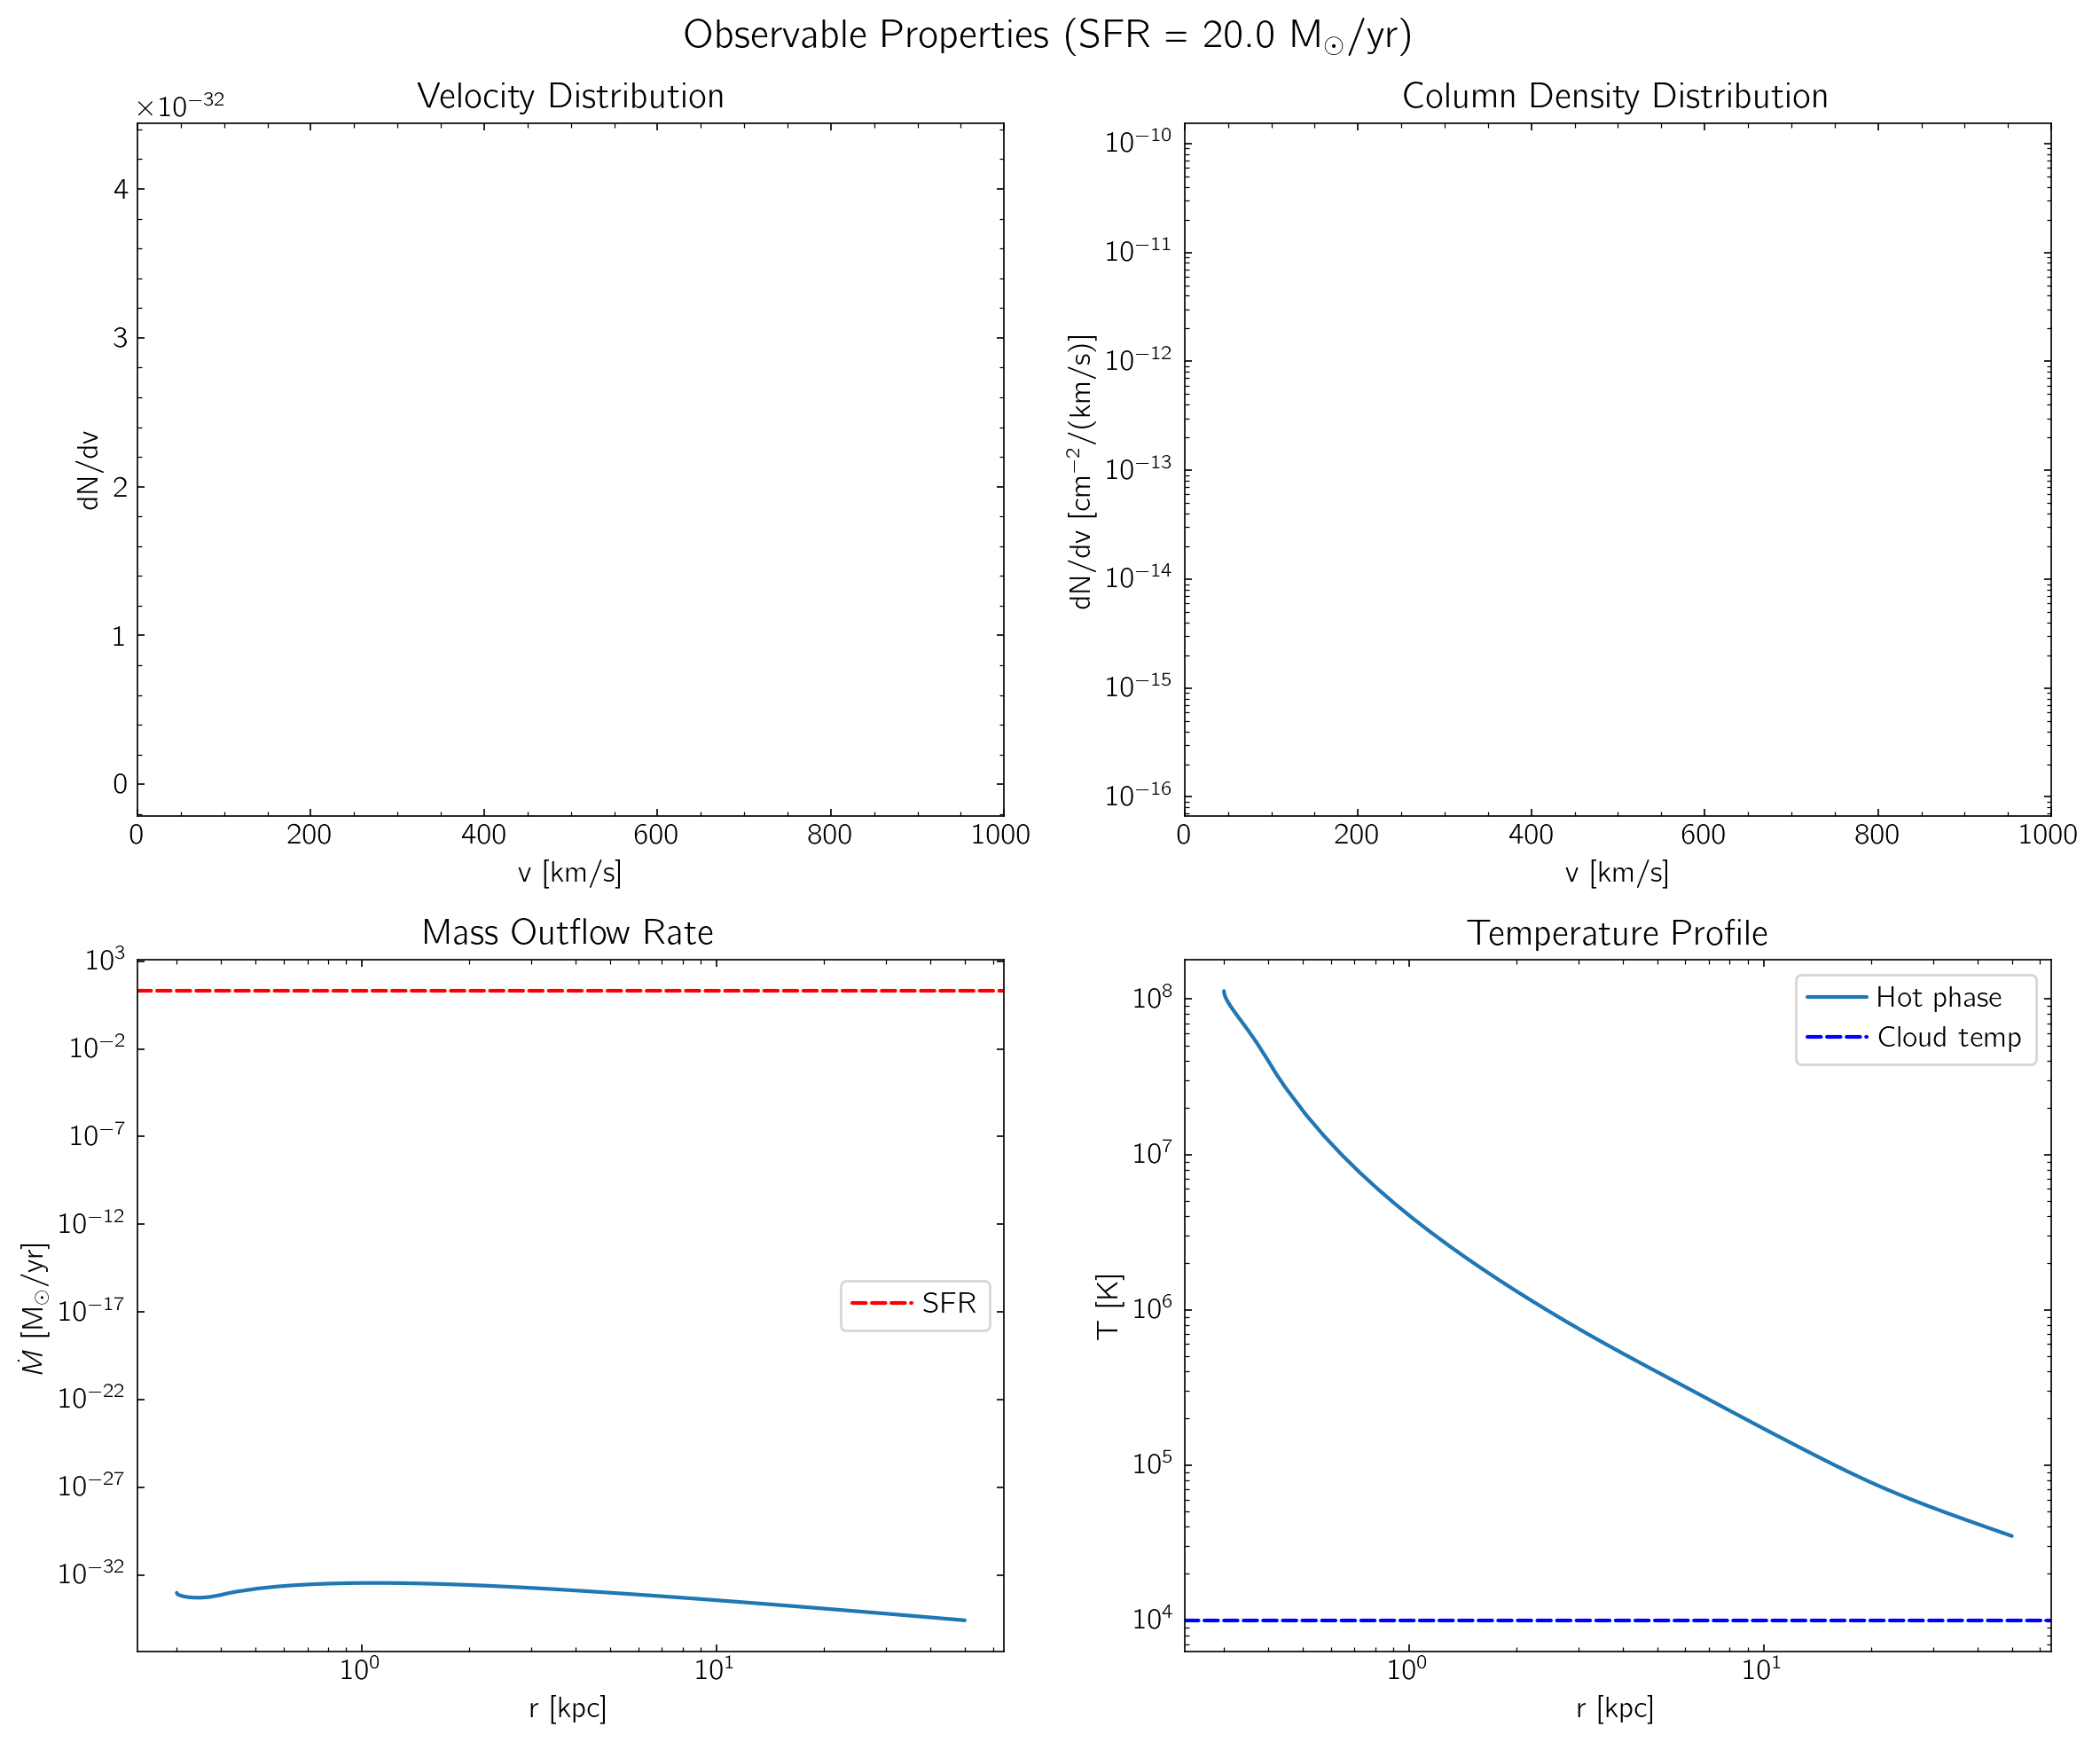

In [ ]:
# Create a model with parameters similar to observed galaxies
model_obs = WindModel(
    SFR=20.0,              # Typical starburst SFR
    v_circ=200.0,          # Massive galaxy
    eta_M=0.1,
    eta_M_cold=2.0,        # High cold mass loading
    N_cloud_species=10,    # More cloud species for better statistics
    cloud_alpha=2.0,       # Salpeter-like
    r_max_kpc=50.0,
    rtol=1e-6
)

print("Running observational comparison model...")
sol_obs = model_obs.run()

# Create observational plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Velocity distribution
v_cloud, dN_dv = sol_obs.calculate_velocity_distribution()
axes[0,0].plot(v_cloud, dN_dv)
axes[0,0].set(xlabel='v [km/s]', ylabel='dN/dv', title='Velocity Distribution')
axes[0,0].set_xlim(0, 1000)

# 2. Column density distribution
v_cloud, dN_dv_col = sol_obs.calculate_column_density_distribution()
axes[0,1].semilogy(v_cloud, dN_dv_col)
axes[0,1].set(xlabel='v [km/s]', ylabel='dN/dv [cm$^{-2}$/(km/s)]', 
              title='Column Density Distribution')
axes[0,1].set_xlim(0, 1000)

# 3. Mass outflow rate vs radius
axes[1,0].loglog(sol_obs.r, sol_obs.Mdot)
axes[1,0].axhline(model_obs.SFR, color='red', linestyle='--', label='SFR')
axes[1,0].set(xlabel='r [kpc]', ylabel='$\dot{M}$ [M$_\odot$/yr]',
              title='Mass Outflow Rate')
axes[1,0].legend()

# 4. Temperature profile
axes[1,1].loglog(sol_obs.r, sol_obs.T, label='Hot phase')
axes[1,1].axhline(model_obs.T_cl, color='blue', linestyle='--', label='Cloud temp')
axes[1,1].set(xlabel='r [kpc]', ylabel='T [K]', title='Temperature Profile')
axes[1,1].legend()

plt.suptitle(f'Observable Properties (SFR = {model_obs.SFR} M$_\odot$/yr)', fontsize=16)
plt.tight_layout()

# Print key observables
if sol_obs.r[-1] >= 10:
    print(f"\nKey observables at 10 kpc:")
    print(f"  Outflow velocity: {sol_obs.v_at_10kpc:.0f} km/s")
    print(f"  Mass loading factor: {sol_obs.mass_loading_at_10kpc:.1f}")
    print(f"  Temperature: {np.interp(10, sol_obs.r, sol_obs.T):.2e} K")

## 9. Advanced Configuration

Let's explore the WindConfig system for fine-tuning physics parameters.

<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:53: SyntaxWarning: invalid escape sequence '\o'
/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_26662/765193311.py:53: SyntaxWarning: invalid escape sequence '\o'
  axes[2].set(xlabel='r [kpc]', ylabel='$M_{cloud,tot}$ [M$_\odot$]', title='Cloud Mass')


Custom configuration parameters:
  mu: 0.7
  metallicity: 2.0
  redshift: 0.0
  half_opening_angle: 1.5707963267948966
  Omwind: 12.56637061435917
  M_cloud_min: 2e+31
  CoolingAreaChiPower: 1.0
  ColdTurbulenceChiPower: -0.5
  TurbulentVelocityChiPower: 0.25
  geometric_factor: 1.0
  Mdot_coefficient: 0.3333333333333333
  Cooling_Factor: 1.0
  drag_coeff: 1.0
  f_turb0: 0.15
  cold_cloud_injection_radial_power: 4
  cold_cloud_injection_radial_extent: 1.231314e+21
  E_SN: 1e+51
  mstar: 100.0
  epsilon: 1e-05

Running custom model...


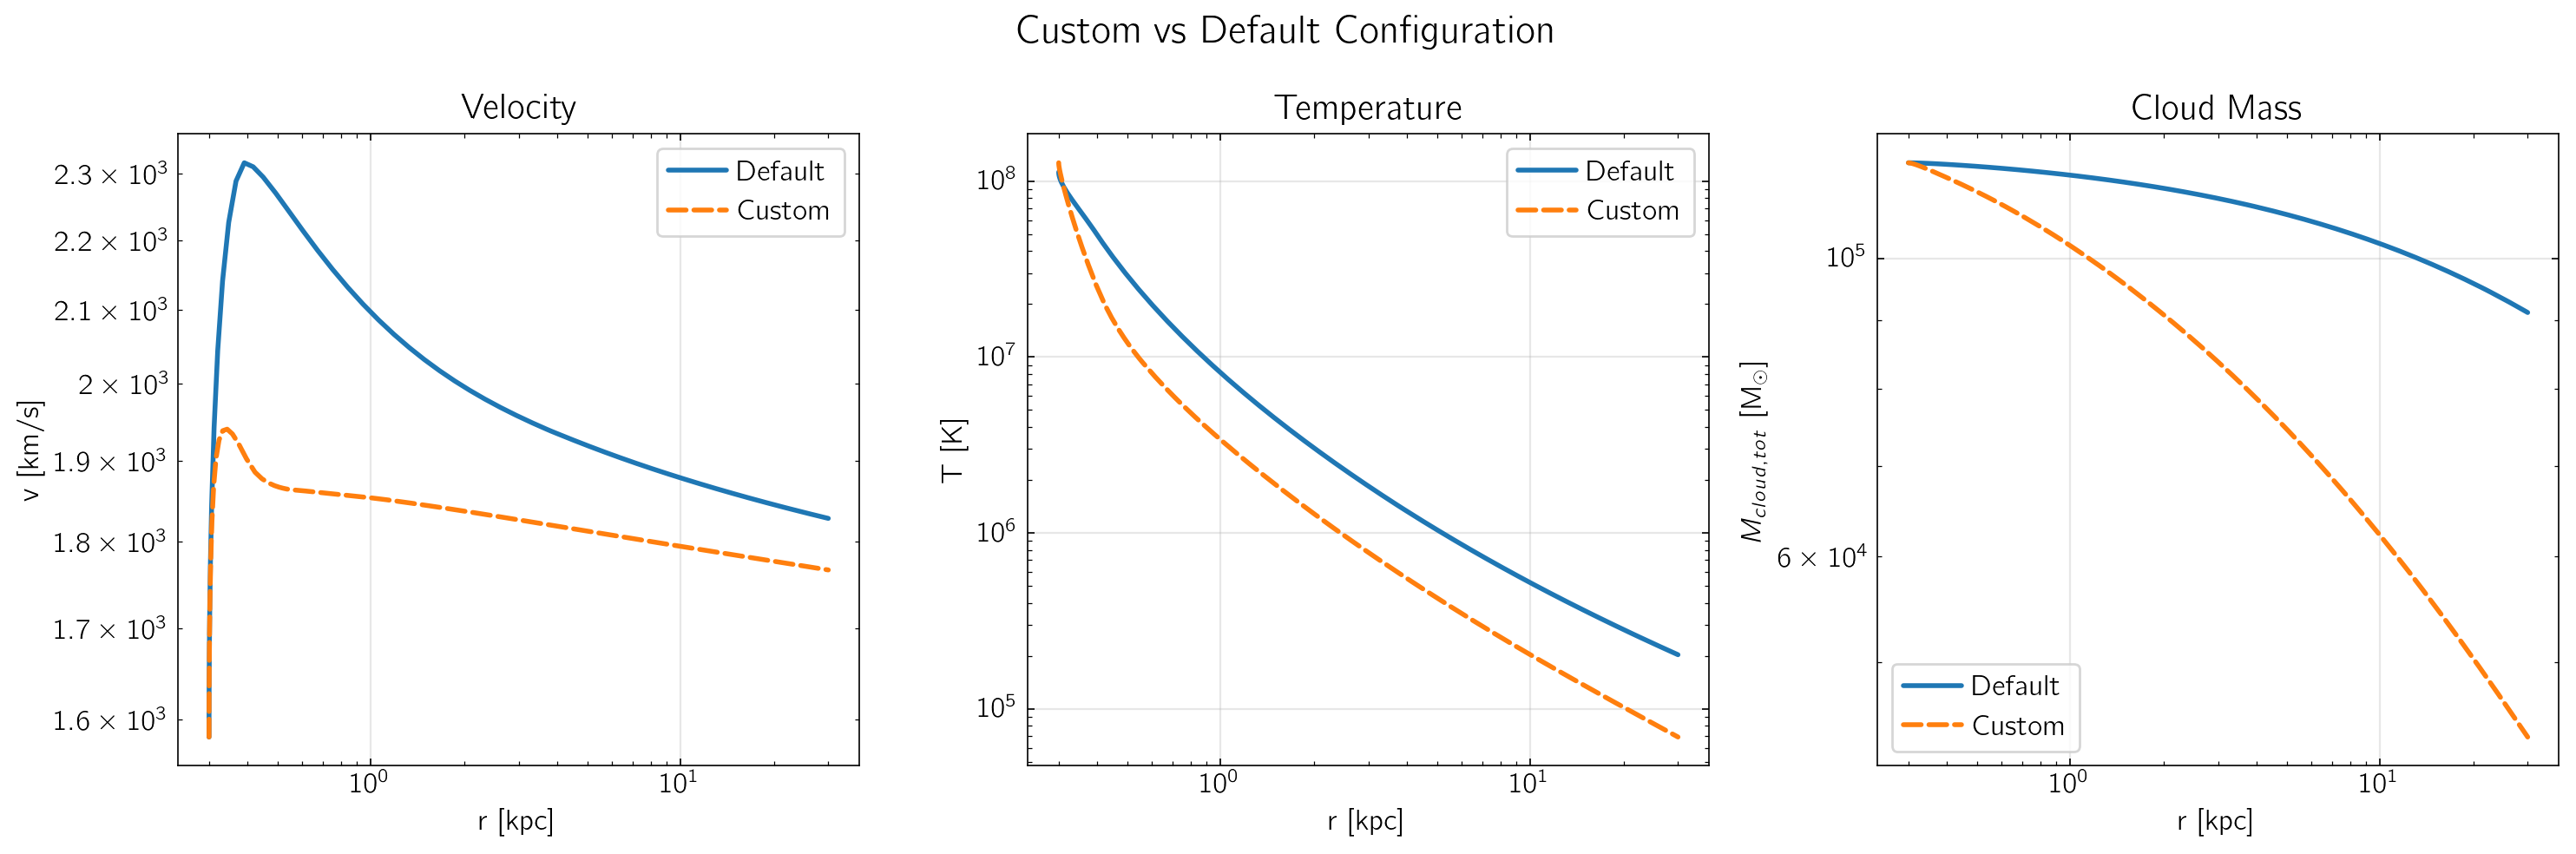

In [ ]:
# Create a custom configuration
custom_config = WindConfig(
    # Thermodynamics
    mu=0.7,                    # Higher molecular weight
    metallicity=2.0,           # Super-solar metallicity
    
    # Turbulence parameters
    f_turb0=0.15,              # Enhanced mixing
    drag_coeff=1.0,            # Higher drag
    
    # Power law modifications
    TurbulentVelocityChiPower=0.25,  # v_turb ∝ χ^0.25
    CoolingAreaChiPower=1.0,         # A ∝ χ
    
    # Cloud injection
    cold_cloud_injection_radial_power=4  # Shallower injection profile
)

# View all parameters
print("Custom configuration parameters:")
for key, value in custom_config.to_dict().items():
    print(f"  {key}: {value}")

# Create model with custom config
model_custom = WindModel(
    SFR=15.0,
    config=custom_config,
    N_cloud_species=7,
    r_max_kpc=30.0,
    rtol=1e-6
)

print("\nRunning custom model...")
sol_custom = model_custom.run()

# Compare with default
model_default = WindModel(SFR=15.0, N_cloud_species=7, r_max_kpc=30.0, rtol=1e-6)
sol_default = model_default.run()

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].loglog(sol_default.r, sol_default.v, label='Default', linewidth=2)
axes[0].loglog(sol_custom.r, sol_custom.v, label='Custom', linewidth=2, linestyle='--')
axes[0].set(xlabel='r [kpc]', ylabel='v [km/s]', title='Velocity')

axes[1].loglog(sol_default.r, sol_default.T, label='Default', linewidth=2)
axes[1].loglog(sol_custom.r, sol_custom.T, label='Custom', linewidth=2, linestyle='--')
axes[1].set(xlabel='r [kpc]', ylabel='T [K]', title='Temperature')

axes[2].loglog(sol_default.r, sol_default.M_cloud_tot/1.989e33, label='Default', linewidth=2)
axes[2].loglog(sol_custom.r, sol_custom.M_cloud_tot/1.989e33, label='Custom', linewidth=2, linestyle='--')
axes[2].set(xlabel='r [kpc]', ylabel='$M_{cloud,tot}$ [M$_\odot$]', title='Cloud Mass')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Custom vs Default Configuration', fontsize=16)
plt.tight_layout()

## 10. Summary and Best Practices

### Key Takeaways:

1. **Model Setup**: Use `WindModel` with key galaxy parameters (SFR, mass loadings)
2. **Configuration**: Use `WindConfig` for detailed physics parameters
3. **Performance**: Adjust `rtol` and `r_max_kpc` for speed vs accuracy
4. **Observables**: Use built-in functions for velocity and column density distributions
5. **Plotting**: Leverage provided plotting functions for consistent visualizations

### Common Issues:

- **Early termination**: Wind may stall if energy/mass loading too low
- **Slow integration**: Reduce tolerance or max radius for faster runs
- **No velocity moments**: Happens if wind terminates very early

### For MCMC Applications:

```python
# Fast configuration for MCMC
model = WindModel(
    SFR=sfr_param,
    eta_M=eta_m_param,
    rtol=1e-4,         # Relaxed tolerance
    r_max_kpc=20,      # Smaller domain
    N_cloud_species=5  # Fewer species
)
```

In [ ]:
# Save this notebook's main results
print("Tutorial completed successfully!")
print(f"\nExplored:")
print(f"  - Basic wind models")
print(f"  - Velocity distributions")
print(f"  - Column density calculations")
print(f"  - Parameter studies (f_turb, eta_M)")
print(f"  - Custom configurations")
print(f"  - Observational comparisons")

Tutorial completed successfully!

Explored:
  - Basic wind models
  - Velocity distributions
  - Column density calculations
  - Parameter studies (f_turb, eta_M)
  - Custom configurations
  - Observational comparisons
